<a href="https://colab.research.google.com/github/boganast2206/stat_pract/blob/main/homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

print("ЗАГРУЗКА ДАННЫХ")

flights_columns = [
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE',
    'CANCELLED', 'CANCELLATION_REASON', 'AIR_TIME', 'FLIGHT_NUMBER'
]

try:
    flights_df = pd.read_csv('flights.csv', usecols=flights_columns, low_memory=False)
    print("Файл flights.csv успешно загружен.")
except FileNotFoundError:
    try:
        flights_df = pd.read_csv('flights.csv.gz', usecols=flights_columns, compression='gzip', low_memory=False)
        print("Файл flights.csv.gz успешно загружен.")
    except FileNotFoundError:
        print("ОШИБКА: Файл flights.csv не найден в папке /content/")
        print("Проверьте, что файл загружен через значок папки слева")
        exit()

try:
    airlines_df = pd.read_csv('airlines.csv')
    airports_df = pd.read_csv('airports.csv')
    print("Справочные файлы airlines.csv и airports.csv успешно загружены.")
except FileNotFoundError:
    print("ОШИБКА: Не найден airlines.csv или airports.csv")
    exit()

print(f"Загружено {len(flights_df):,} записей о рейсах.")

print("ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА")

flights_df['FLIGHT_DATE'] = pd.to_datetime(flights_df[['YEAR', 'MONTH', 'DAY']])

flights_df = flights_df.merge(airlines_df, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights_df.rename(columns={'AIRLINE_x': 'AIRLINE_CODE', 'AIRLINE_y': 'AIRLINE_NAME'}, inplace=True)

flights_df = flights_df.merge(airports_df, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
flights_df.rename(columns={'AIRPORT': 'ORIGIN_AIRPORT_NAME', 'CITY': 'ORIGIN_CITY', 'STATE': 'ORIGIN_STATE'}, inplace=True)

airports_df_for_merge = airports_df.add_suffix('_DEST').rename(columns={'IATA_CODE_DEST': 'DESTINATION_AIRPORT'})
flights_df = flights_df.merge(airports_df_for_merge, left_on='DESTINATION_AIRPORT', right_on='DESTINATION_AIRPORT', how='left')
flights_df.rename(columns={'AIRPORT_DEST': 'DESTINATION_AIRPORT_NAME', 'CITY_DEST': 'DESTINATION_CITY', 'STATE_DEST': 'DESTINATION_STATE'}, inplace=True)

flights_df.drop(columns=['IATA_CODE', 'IATA_CODE_DEST', 'AIRLINE_CODE', 'YEAR', 'MONTH', 'DAY'], inplace=True, errors='ignore')

initial_len = len(flights_df)
flights_df = flights_df.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])
print(f"Удалено {initial_len - len(flights_df):,} записей с пропущенными задержками.")

flights_df['IS_DELAYED'] = (flights_df['DEPARTURE_DELAY'] > 15).astype(int)

print(f"Итоговое количество записей для анализа: {len(flights_df):,}")


ЗАГРУЗКА ДАННЫХ
Файл flights.csv успешно загружен.
Справочные файлы airlines.csv и airports.csv успешно загружены.
Загружено 5,819,079 записей о рейсах.
ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА
Удалено 105,071 записей с пропущенными задержками.
Итоговое количество записей для анализа: 5,714,008


##РЕЗУЛЬТАТ 1
Задержки по дням недели

Статистика по дням недели:
          avg_delay  median_delay  flight_count
DAY_NAME                                       
Пн        10.755533          -1.0        841794
Вт         9.104848          -2.0        827399
Ср         8.597665          -2.0        843242
Чт         9.875447          -1.0        857886
Пт         9.373953          -1.0        851387
Сб         7.734828          -2.0        689745
Вс         9.327305          -2.0        802555


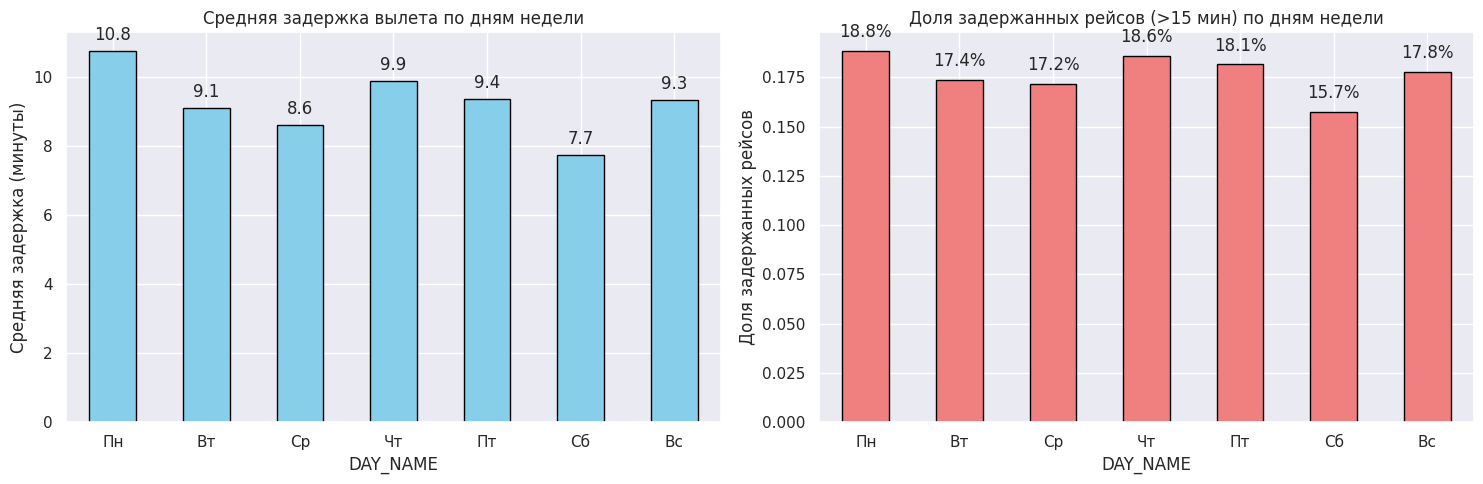

In [ ]:
days_map = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}
flights_df['DAY_NAME'] = flights_df['DAY_OF_WEEK'].map(days_map)

delay_by_day = flights_df.groupby('DAY_NAME').agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    median_delay=('DEPARTURE_DELAY', 'median'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
print("Статистика по дням недели:")
print(delay_by_day)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

delay_by_day['avg_delay'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Средняя задержка вылета по дням недели')
axes[0].set_ylabel('Средняя задержка (минуты)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(delay_by_day['avg_delay']):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', va='bottom')

delayed_ratio_by_day = flights_df.groupby('DAY_NAME')['IS_DELAYED'].mean().reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
delayed_ratio_by_day.plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Доля задержанных рейсов (>15 мин) по дням недели')
axes[1].set_ylabel('Доля задержанных рейсов')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(delayed_ratio_by_day):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Вывод

*   **Понедельник** — самый проблемный день
*   **Четверг** - второе место (высокие задержки)
*   **Среда и суббота** — самые надежные дни для перелетов

##РЕЗУЛЬТАТ 2

Авиакомпании-лидеры по задержкам

Топ-10 авиакомпаний с наибольшей средней задержкой:
                                   mean   count
AIRLINE_NAME                                   
Frontier Airlines Inc.        21.456574   12504
American Eagle Airlines Inc.  17.138520   50823
Spirit Air Lines              14.955824   16570
JetBlue Airways               14.407304   39182
United Air Lines Inc.         14.354517   73060
Skywest Airlines Inc.         11.478422   89722
Atlantic Southeast Airlines   10.365349   90642
American Airlines Inc.        10.364189   80656
Southwest Airlines Co.         9.618182  185562
Virgin America                 9.502227    8757


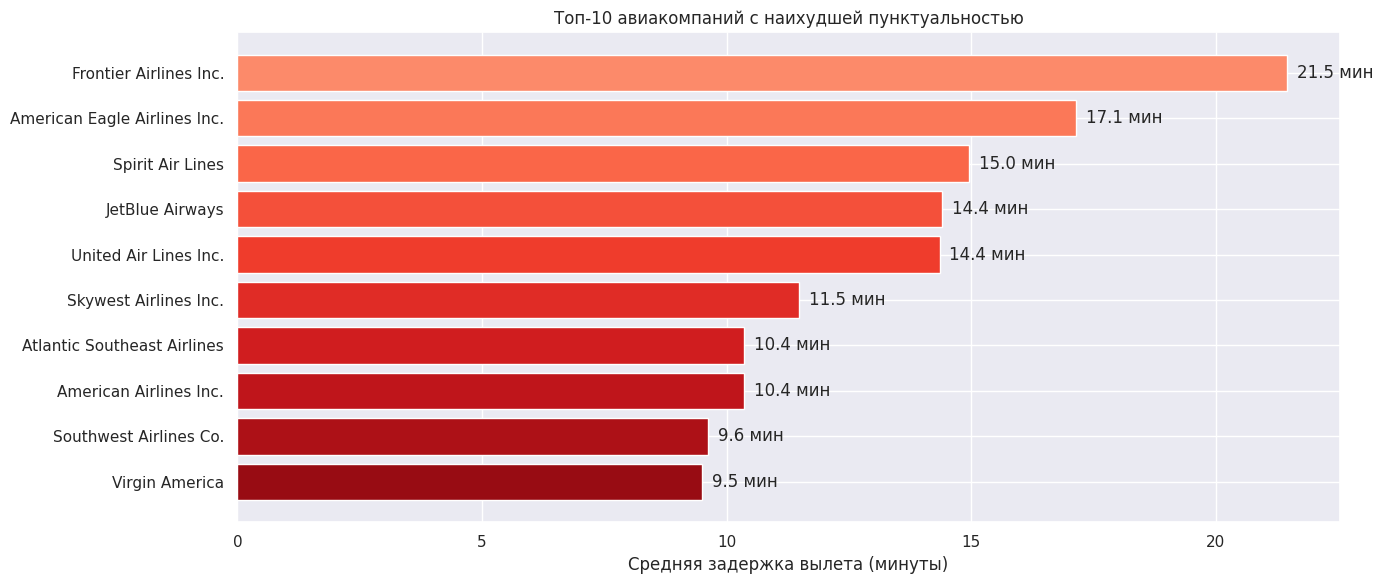

In [ ]:


airline_delays = flights_df.groupby('AIRLINE_NAME')['DEPARTURE_DELAY'].agg(['mean', 'count']).sort_values('mean', ascending=False)
airline_delays = airline_delays[airline_delays['count'] > 1000]
top10_delayed_airlines = airline_delays.head(10)

print("Топ-10 авиакомпаний с наибольшей средней задержкой:")
print(top10_delayed_airlines)

plt.figure(figsize=(14, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))
plt.barh(top10_delayed_airlines.index, top10_delayed_airlines['mean'], color=colors)
plt.xlabel('Средняя задержка вылета (минуты)')
plt.title('Топ-10 авиакомпаний с наихудшей пунктуальностью')
plt.gca().invert_yaxis()
for i, (index, row) in enumerate(top10_delayed_airlines.iterrows()):
    plt.text(row['mean'] + 0.2, i, f'{row["mean"]:.1f} мин', va='center')
plt.tight_layout()
plt.show()



##Вывод

Авиакомпания Frontier Airlines лидирует по средней задержке, за ней следуют Spirit и Southwest

##РЕЗУЛЬТАТ 3

Влияние расстояния полета на задержки

Статистика задержек по группам расстояний:
                     mean  median   count
DISTANCE_GROUP                           
0-500            9.792029    -2.0  326396
501-1000        10.776006    -1.0  301843
1001-1500       12.162616    -1.0  133960
1501-2000       11.638267     0.0   56727
2000+           10.957272    -1.0   51255


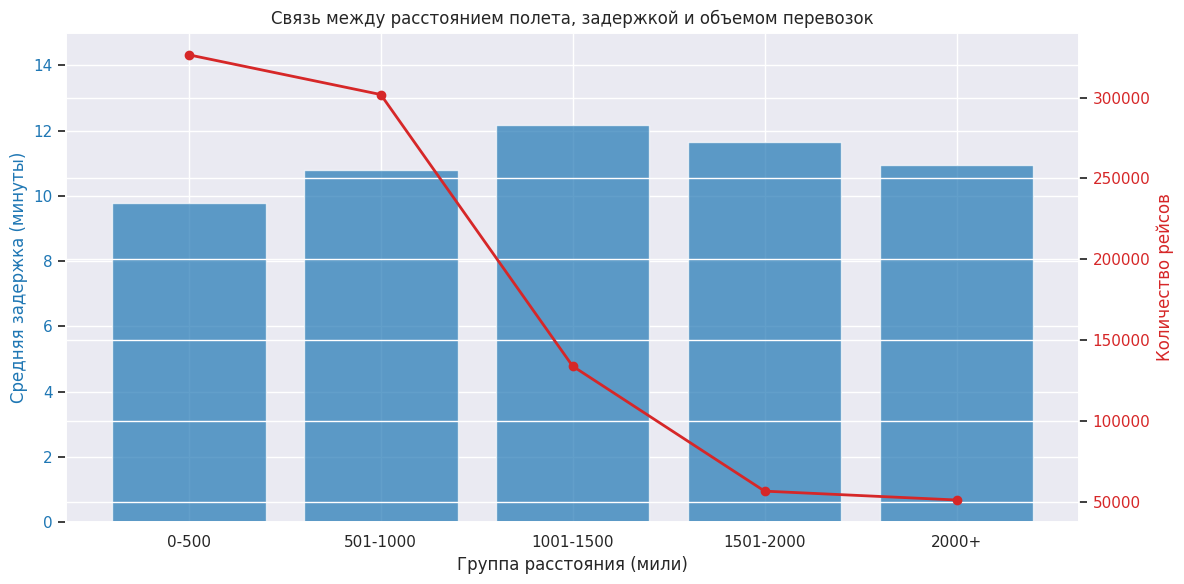

In [ ]:
bins = [0, 500, 1000, 1500, 2000, 5000]
labels = ['0-500', '501-1000', '1001-1500', '1501-2000', '2000+']
flights_df['DISTANCE_GROUP'] = pd.cut(flights_df['DISTANCE'], bins=bins, labels=labels)

delay_by_distance = flights_df.groupby('DISTANCE_GROUP', observed=True)['DEPARTURE_DELAY'].agg(['mean', 'median', 'count'])
print("Статистика задержек по группам расстояний:")
print(delay_by_distance)

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Группа расстояния (мили)')
ax1.set_ylabel('Средняя задержка (минуты)', color=color)
ax1.bar(delay_by_distance.index, delay_by_distance['mean'], color=color, alpha=0.7, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 15)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Количество рейсов', color=color)
ax2.plot(delay_by_distance.index, delay_by_distance['count'], color=color, marker='o', linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Связь между расстоянием полета, задержкой и объемом перевозок')
fig.tight_layout()
plt.show()



##Вывод

Средняя задержка растет с увеличением расстояния

##РЕЗУЛЬТАТ 4

Связь задержек вылета и прилета

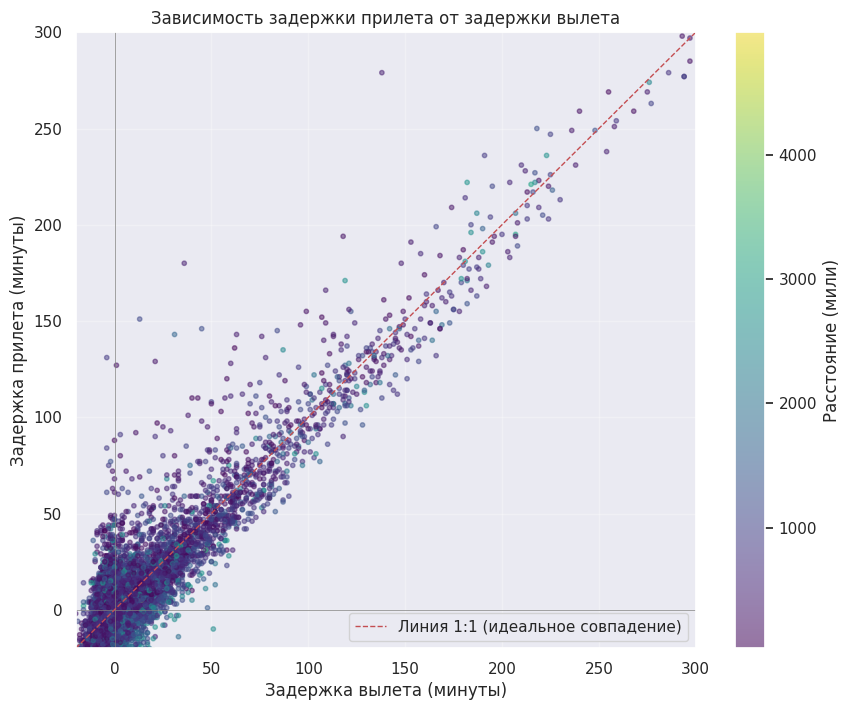

In [ ]:

plt.figure(figsize=(10, 8))

sample_df = flights_df.sample(n=10000, random_state=42)

scatter = plt.scatter(sample_df['DEPARTURE_DELAY'], sample_df['ARRIVAL_DELAY'],
                      c=sample_df['DISTANCE'], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Расстояние (мили)')
plt.xlabel('Задержка вылета (минуты)')
plt.ylabel('Задержка прилета (минуты)')
plt.title('Зависимость задержки прилета от задержки вылета')
plt.xlim(-20, 300)
plt.ylim(-20, 300)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.plot([-20, 300], [-20, 300], 'r--', linewidth=1, label='Линия 1:1 (идеальное совпадение)')
plt.legend()
plt.show()

correlation = flights_df['DEPARTURE_DELAY'].corr(flights_df['ARRIVAL_DELAY'])


##Вывод

Задержка вылета почти гарантированно приводит к задержке прилета

##РЕЗУЛЬТАТ 5

География задержек — проблемные аэропорты

Топ-10 аэропортов с наибольшей средней задержкой вылета:
  ORIGIN_AIRPORT ORIGIN_CITY       mean
0            ORD     Chicago  20.649165
1            LGA    New York  17.188645
2            JFK    New York  16.768628
3            IAD   Chantilly  16.073516
4            DEN      Denver  15.208201
5            BOS      Boston  14.305237
6            DTW     Detroit  14.002083
7            EWR      Newark  13.456819
8            BWI   Baltimore  12.996144
9            MDW     Chicago  12.694852


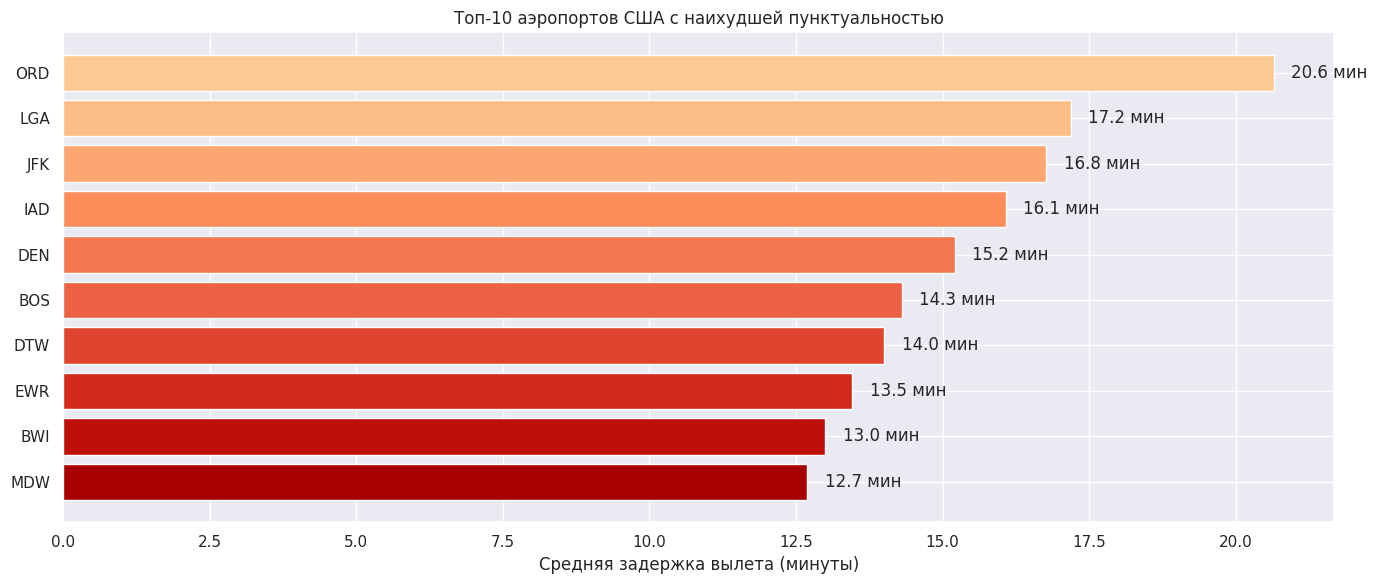

In [ ]:

airport_dep_delays = flights_df.groupby(['ORIGIN_AIRPORT', 'ORIGIN_CITY'])['DEPARTURE_DELAY'].agg(['mean', 'count']).sort_values('mean', ascending=False)
airport_dep_delays = airport_dep_delays[airport_dep_delays['count'] > 5000]
top10_delayed_airports = airport_dep_delays.head(10).reset_index()

print("Топ-10 аэропортов с наибольшей средней задержкой вылета:")
print(top10_delayed_airports[['ORIGIN_AIRPORT', 'ORIGIN_CITY', 'mean']])

plt.figure(figsize=(14, 6))
colors = plt.cm.OrRd(np.linspace(0.3, 0.9, 10))
bars = plt.barh(range(10), top10_delayed_airports['mean'], color=colors, tick_label=top10_delayed_airports['ORIGIN_AIRPORT'])
plt.xlabel('Средняя задержка вылета (минуты)')
plt.title('Топ-10 аэропортов США с наихудшей пунктуальностью')
plt.gca().invert_yaxis()
for i, (index, row) in enumerate(top10_delayed_airports.iterrows()):
    plt.text(row['mean'] + 0.3, i, f'{row["mean"]:.1f} мин', va='center')
plt.tight_layout()
plt.show()


##Вывод

Крупные аэропорты (ORD - Чикаго, DFW - Даллас, ATL - Атланта) лидируют по задержкам